# photoD tutorial: stellar parameters from colors

In this notebook we estimate three properties of stars from their colors: the absolute magnitude $M_r$, the
extinction by interstellar dust $A_r$, and the metallicity [Fe/H]. Once $M_r$ and $A_r$ are known, the distance
to a star follows from its apparent magnitude. That is why the method is called photoD, for photometric
distances.

We work with a simulated catalog of 619,581 stars, so the true values are known and we can check how well the
method does. We build it up in small steps, try it on a single star, run it on the whole catalog, compare the estimates with
the truth, and finally turn them into distances.

Everything the notebook needs is in this folder. Run the cells from top to bottom. Two steps are slow (the
priors, about 7 minutes, and the run over all stars, about an hour on four cores). Their results are saved in
`outputs/` and simply loaded the next time. For a quick test, set `N_STARS = 20000` in the settings.

## Background

Astronomers measure brightness in magnitudes, $m = -2.5\log_{10}(\mathrm{flux}) + \mathrm{const}$. Note that the
scale runs backwards: fainter stars have larger magnitudes. The Legacy Survey of Space and Time (LSST) measures
magnitudes in six filters, from the ultraviolet to the near infrared: $u, g, r, i, z, y$. We use the first five.

How bright a star looks depends on how luminous it is and on how far away it is. The absolute magnitude $M_r$
is the magnitude the star would have at a distance of 10 parsecs (1 pc ≈ 3.26 light years), so it measures
luminosity. The apparent magnitude $r$ (the magnitude we actually measure in the $r$ filter), the absolute
magnitude, the distance $d$ and the dust extinction $A_r$ are related by

$$ r = M_r + 5\log_{10}\!\left(\frac{d}{10\,\mathrm{pc}}\right) + A_r . $$

The middle term is called the distance modulus. We measure $r$; if we can also find $M_r$ and $A_r$, we can solve
for $d$.

A color is the difference between two magnitudes, for example $g - r$. Distance makes a star fainter by the same
amount in every filter, so it drops out of colors. Colors depend only on the kind of star and on dust. We use four
of them: $u-g$, $g-r$, $r-i$ and $i-z$.

Most stars are main-sequence stars or red giants, and their colors are far from random. In color space they lie
along a narrow band called the stellar locus. Where a star sits along the band is set by its temperature. For
main-sequence stars the temperature also fixes the luminosity, so the colors tell us $M_r$. The metallicity
[Fe/H] is the logarithm of the star's iron abundance relative to the Sun ([Fe/H] = 0 is solar, −1 is ten times
less iron). It moves stars slightly off the band, mainly in $u-g$: metal-poor stars are bluer.

Dust dims blue light more than red light, so it makes stars both fainter and redder. The extinction in every
filter is a fixed multiple of $A_r$. So each color becomes redder by a known amount per magnitude of $A_r$.

To go from colors to parameters we use Bayes' theorem. We set up a grid of possible parameter values
$\theta = (M_r, [\mathrm{Fe/H}], A_r)$, and at every grid point we compute

$$ \mathrm{posterior}(\theta) \propto \mathrm{likelihood}(\theta) \times \mathrm{prior}(\theta) . $$

The likelihood says how well the model colors at $\theta$ match the measured colors. For measurement errors that
follow a Gaussian distribution it is $e^{-\chi^2/2}$, where

$$ \chi^2 = \sum_{\mathrm{colors}} \left( \frac{\mathrm{measured} - \mathrm{model}}{\mathrm{error}} \right)^2 . $$

The prior says how common each kind of star is, before looking at its colors. Some very different stars have
nearly the same colors (a giant and a dwarf, for example), and the prior helps decide between them.

The posterior is a 3-D array of probabilities. Adding it up over two of the parameters leaves the probability
distribution of the third. We take the mean of that distribution as our estimate and its standard deviation as
the uncertainty.

## 1. Setup

In [1]:
import os
# numpy may start several threads in each process; we use one process per CPU core instead (section 7)
for var in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS'):
    os.environ.setdefault(var, '1')

import time
import multiprocessing as mp
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import griddata
from scipy.stats import gaussian_kde

Files and run options. If you change any of the model settings further down, set `FORCE_RERUN = True` once,
otherwise the saved results from the old settings are loaded.

In [2]:
LOCUS_FILE = Path('data/stellar_locus_v1.3.txt')
CATALOG_FILE = Path('data/simulated_catalog.txt.gz')
OUT_DIR = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

N_STARS = None           # how many stars to process; None means all of them
N_WORKERS = os.cpu_count()
FORCE_RERUN = False      # redo the slow steps even if their results are saved
SEED = 42                # for the random choices, so that they are repeatable

PRIOR_FILE = OUT_DIR / 'priors.npz'
RESULTS_FILE = OUT_DIR / ('bayes_estimates.csv' if N_STARS is None else f'bayes_estimates_{N_STARS}.csv')

Model settings. Each is explained in the section where it is used.

In [3]:
COLORS = ['ug', 'gr', 'ri', 'iz']

# extinction in each filter relative to the r filter (A_u = 1.81 A_r, and so on)
EXTINCTION = {'u': 1.810, 'g': 1.400, 'r': 1.000, 'i': 0.759, 'z': 0.561}
# how much redder each color gets per magnitude of A_r, e.g. u-g by 1.81 - 1.40 = 0.41
REDDENING = {c: EXTINCTION[c[0]] - EXTINCTION[c[1]] for c in COLORS}

# stellar locus (section 3)
GI_MIN, GI_MAX = 0.2, 3.55       # range of g-i color we use
THIN_MR, THIN_FEH = 10, 2        # keep every 10th Mr and every 2nd [Fe/H] value
COLOR_CORRECTIONS = True         # small corrections to u-g and i-z

# dust (section 4): A_r is allowed between 0 and AR_SCALE * A_r(dust map) + AR_OFFSET
AR_SCALE, AR_OFFSET = 1.3, 0.1

# priors (section 5): maps on a grid of [Fe/H] and Mr, one per bin of apparent r magnitude
PRIOR_FEH = np.linspace(-2.5, 1.0, 36)
PRIOR_MR = np.linspace(17.0, -2.0, 96)
R_BINS = np.linspace(14, 27, 27)     # bin centers 14, 14.5, ..., 27
R_HALF_WIDTH = 0.5                   # each bin is 1 mag wide, so neighboring bins overlap

print('reddening per magnitude of A_r:', {c: round(v, 3) for c, v in REDDENING.items()})

reddening per magnitude of A_r: {'ug': 0.41, 'gr': 0.4, 'ri': 0.241, 'iz': 0.198}


## 2. The simulated catalog

The catalog contains simulated stars in a small patch of sky, drawn from a model of the Milky Way. Their colors
were computed from the stellar locus, reddened by dust, and given the measurement noise that LSST will have.
For every star we know the true $M_r$, [Fe/H] and $A_r$ as well as the "measured" magnitudes and colors.

We read only the columns we need and rename a few of them:

| column | meaning |
|---|---|
| `FeH`, `Mr`, `Ar` | true metallicity, absolute magnitude and extinction |
| `DM` | true distance modulus, $5\log_{10}(d/10\,\mathrm{pc})$ |
| `rmag0` | true $r$ magnitude, without noise |
| `rmag` | measured $r$ magnitude |
| `ug`, `gr`, `ri`, `iz` | measured colors, including noise and dust |
| `uErr` ... `zErr` | error of each measured magnitude |

A color is the difference of two magnitudes, so its error is the two magnitude errors added in quadrature, for
example $\sigma_{u-g} = \sqrt{\sigma_u^2 + \sigma_g^2}$.

In [4]:
def read_catalog(path, nrows=None):
    """Read the columns we need from the catalog and add the error of each color."""
    columns = ['FeH', 'Mr', 'Ar', 'DM', 'rmagObs0', 'rmag',
               'ugObs', 'grObs', 'riObs', 'izObs', 'uErr', 'gErr', 'rErr', 'iErr', 'zErr']
    stars = pd.read_csv(path, sep=r'\s+', usecols=columns, nrows=nrows)
    stars = stars.rename(columns={'rmagObs0': 'rmag0', 'ugObs': 'ug', 'grObs': 'gr', 'riObs': 'ri', 'izObs': 'iz'})
    for color in COLORS:
        band1, band2 = color   # e.g. 'ug' -> 'u', 'g'
        stars[color + 'Err'] = np.sqrt(stars[band1 + 'Err']**2 + stars[band2 + 'Err']**2)
    return stars


catalog = read_catalog(CATALOG_FILE)
if N_STARS is not None:
    catalog = catalog.sample(n=N_STARS, random_state=SEED).sort_index()

print(f'{len(catalog):,} stars')
catalog[['FeH', 'Mr', 'Ar', 'rmag', 'uErr', 'rErr']].describe().loc[['min', '50%', 'max']].round(2)

619,581 stars


,FeH,Mr,Ar,rmag,uErr,rErr
min,-2.09,-1.99,0.01,3.19,0.00,0.00
50%,-1.20,8.91,0.18,23.96,0.85,0.02
max,0.47,16.32,0.51,26.33,9.96,0.12


Most of the stars are faint, as the histogram on the left shows. The median error of the $u$ magnitude is almost
0.9 mag, so for many stars the $u-g$ color is very uncertain. That matters, because $u-g$ is the color that
carries the metallicity information. The right panel shows it for the stars with precise $u-g$: at the same
$g-r$, metal-poor stars (blue) have a smaller $u-g$ than metal-rich ones (red).

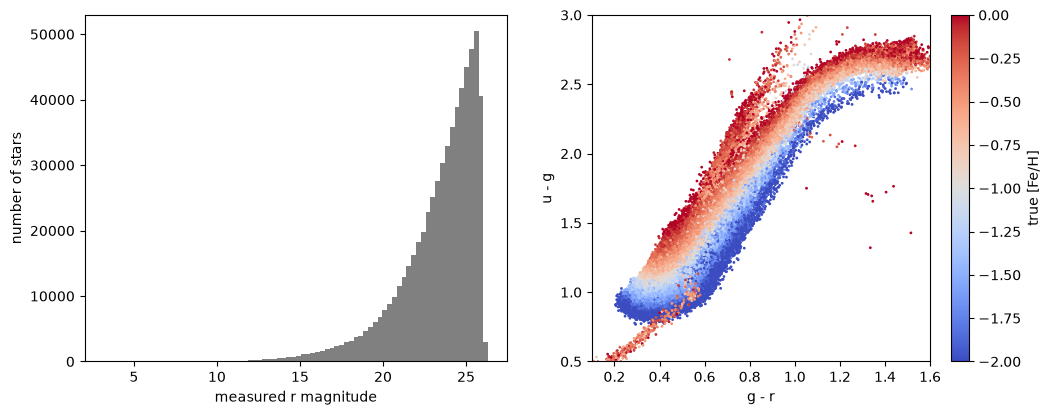

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.hist(catalog['rmag'], bins=80, color='grey')
ax1.set_xlabel('measured r magnitude')
ax1.set_ylabel('number of stars')

precise = catalog[catalog['ugErr'] < 0.03]
points = ax2.scatter(precise['gr'], precise['ug'], c=precise['FeH'], s=1, cmap='coolwarm', vmin=-2, vmax=0)
ax2.set(xlim=(0.1, 1.6), ylim=(0.5, 3.0), xlabel='g - r', ylabel='u - g')
plt.colorbar(points, ax=ax2, label='true [Fe/H]')
plt.show()

## 3. The model: the stellar locus

Our model is a table with the colors of dust-free stars on a grid of $M_r$ (−1 to 28 in steps of 0.01) and
[Fe/H] (−2.5 to 0 in steps of 0.05). The rows are sorted by [Fe/H], and within each [Fe/H] by $M_r$.

We also apply two small corrections to the table colors, one to $u-g$ and one to $i-z$. The simulated catalog was
made with these corrections, so our model has to include them too. Besides the table columns we add `gi`, the
$g-i$ color, which we use below to pick the part of the table we need. The $z-y$ color is not used.

In [6]:
def read_locus(path, color_corrections=False):
    """Read the stellar locus table, optionally with the u-g and i-z corrections."""
    locus = pd.read_csv(path, sep=r'\s+', comment='#', header=None,
                        names=['Mr', 'FeH', 'ug', 'gr', 'ri', 'iz', 'zy'])
    locus['gi'] = locus['gr'] + locus['ri']

    if color_corrections:
        # u-g: a little redder for redder stars, and constant for g-i > 1.8
        ug_corrected = locus['ug'] + 0.02 * (2 + locus['FeH']) * locus['gi']
        ug_red_end = 2.53 + 0.13 * (1 + locus['FeH'])
        locus['ug'] = np.where(locus['gi'] > 1.8, ug_red_end, ug_corrected)
        # i-z: small offsets that depend on r-i and [Fe/H]
        locus['iz'] += 0.08 * locus['ri'] - 0.09 * locus['ri']**2 + 0.008 * locus['ri']**5
        locus['iz'] += 0.01 * (2.5 + locus['FeH'])
    return locus


locus = read_locus(LOCUS_FILE, color_corrections=COLOR_CORRECTIONS)
in_range = (locus['gi'] > GI_MIN) & (locus['gi'] < GI_MAX)
print(f'{len(locus):,} rows in the table, {in_range.sum():,} of them with {GI_MIN} < g-i < {GI_MAX}')
locus.head()

147,951 rows in the table, 79,509 of them with 0.2 < g-i < 3.55


,Mr,FeH,ug,gr,ri,iz,zy,gi
0,-1.00,-2.5,1.372070,0.5780,0.2650,0.182990,0.0803,0.8430
1,-0.99,-2.5,1.370876,0.5776,0.2648,0.182784,0.0802,0.8424
2,-0.98,-2.5,1.369783,0.5772,0.2645,0.182474,0.0801,0.8417
3,-0.97,-2.5,1.368589,0.5768,0.2643,0.182267,0.0800,0.8411
4,-0.96,-2.5,1.367396,0.5764,0.2640,0.182058,0.0799,0.8404


Here is what the table looks like for three metallicities. The left panel is a color-magnitude diagram. The
main sequence runs from hot, luminous stars at the top left to cool, faint stars at the bottom right, and the
branch that rises at $M_r < 4$ is the red giant branch. The right panel shows the same stars in the
$u-g$ vs. $g-r$ plane. Compare it with the right panel above: the tracks are separated by metallicity just like
the simulated stars.

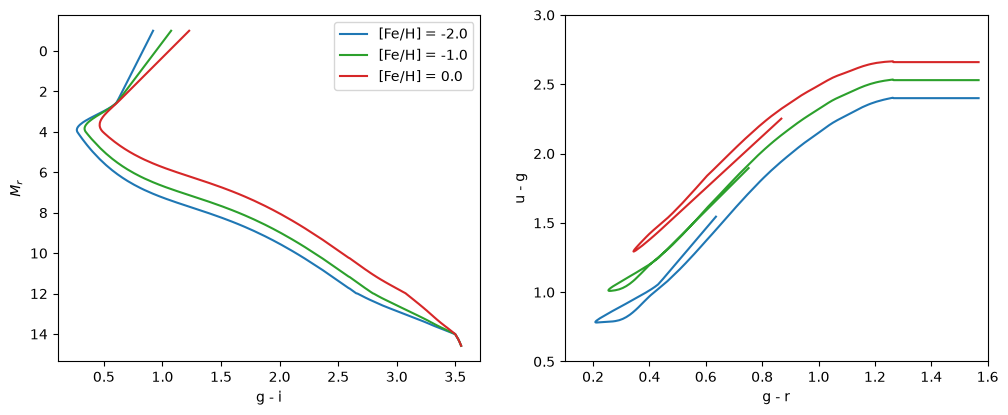

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
for feh, line_color in [(-2.0, 'tab:blue'), (-1.0, 'tab:green'), (0.0, 'tab:red')]:
    track = locus[np.isclose(locus['FeH'], feh) & in_range]
    ax1.plot(track['gi'], track['Mr'], color=line_color, label=f'[Fe/H] = {feh}')
    ax2.plot(track['gr'], track['ug'], color=line_color)

ax1.invert_yaxis()   # bright stars at the top
ax1.set(xlabel='g - i', ylabel='$M_r$')
ax2.set(xlim=(0.1, 1.6), ylim=(0.5, 3.0), xlabel='g - r', ylabel='u - g')
ax1.legend()
plt.show()

We don't need the full table. First we keep only $0.2 < g-i < 3.55$, the range of main-sequence stars and
giants. For every metallicity this leaves $M_r$ between −1 and 14.58, so the table is still a complete rectangular
grid. Then we thin it out: every 10th $M_r$ and every 2nd [Fe/H] value, i.e. steps of 0.1 in both. This makes the
fit about 20 times faster at little cost in accuracy.

In [8]:
def thin_locus(locus, thin_mr, thin_feh):
    """Keep every thin_mr-th Mr value and every thin_feh-th [Fe/H] value of the table."""
    feh_values = np.sort(locus['FeH'].unique())
    mr_values = np.sort(locus['Mr'].unique())
    # every thin-th value; the second slice drops a leftover value at the end when the count doesn't divide evenly
    keep_feh = feh_values[::thin_feh][:len(feh_values) // thin_feh]
    keep_mr = mr_values[::thin_mr][:len(mr_values) // thin_mr]
    keep = locus['FeH'].isin(keep_feh) & locus['Mr'].isin(keep_mr)
    return locus[keep].reset_index(drop=True)


grid = thin_locus(locus[in_range], THIN_MR, THIN_FEH)
feh_grid = np.sort(grid['FeH'].unique())
mr_grid = np.sort(grid['Mr'].unique())

print(f'[Fe/H]: {feh_grid[0]} to {feh_grid[-1]}, {feh_grid.size} values')
print(f'Mr:     {mr_grid[0]} to {mr_grid[-1]}, {mr_grid.size} values')
print(f'{len(grid):,} grid points')

[Fe/H]: -2.5 to -0.1, 25 values
Mr:     -1.0 to 14.4, 155 values
3,875 grid points


## 4. Adding dust

The table is for stars without dust. A star behind $A_r$ magnitudes of dust has every color shifted by the
reddening of that color (from the settings) times $A_r$:

$$ \mathrm{color}(M_r, [\mathrm{Fe/H}], A_r) = \mathrm{color}_{\mathrm{table}}(M_r, [\mathrm{Fe/H}]) + \mathrm{reddening} \times A_r . $$

So the grid gets a third dimension, a list of $A_r$ values.

For the dust we use a flat prior: every $A_r$ from 0 up to a maximum is equally likely. The maximum is
$1.3\,A_r^{\mathrm{map}} + 0.1$, where $A_r^{\mathrm{map}}$ is the extinction from a map of the dust in the sky;
the extra room allows for errors in the map. In our simulation we use the true $A_r$ in place of the map value.

To keep the grid small, we prepare three lists of $A_r$ values: 0 to 0.3 and 0 to 0.8 in steps of 0.01, and 0 to
2.5 in steps of 0.02. Each star uses the shortest list that reaches its maximum, cut at that maximum.

In [9]:
AR_GRIDS = {'short': np.linspace(0, 0.3, 31),
            'medium': np.linspace(0, 0.8, 81),
            'long': np.linspace(0, 2.5, 126)}


def choose_ar_grid(ar_max):
    """The shortest list of Ar values that reaches ar_max, cut at ar_max."""
    if ar_max < AR_GRIDS['short'].max():
        name = 'short'
    elif ar_max < AR_GRIDS['medium'].max():
        name = 'medium'
    else:
        name = 'long'
    return name, AR_GRIDS[name][AR_GRIDS[name] <= ar_max]


def make_model_colors(grid):
    """Model colors on the full 3-D grid: one array of shape (n_feh, n_mr, n_ar, 4) per Ar list."""
    n_feh, n_mr = grid['FeH'].nunique(), grid['Mr'].nunique()
    # the rows are sorted by [Fe/H] and then Mr, so a reshape gives an array indexed by ([Fe/H], Mr)
    dust_free = np.stack([grid[c].to_numpy(float).reshape(n_feh, n_mr) for c in COLORS], axis=-1)
    model = {}
    for name, ar_values in AR_GRIDS.items():
        shift = np.stack([ar_values * REDDENING[c] for c in COLORS], axis=-1)   # shape (n_ar, 4)
        # None inserts an axis of length 1; adding (n_feh, n_mr, 1, 4) and (1, 1, n_ar, 4) gives (n_feh, n_mr, n_ar, 4)
        model[name] = dust_free[:, :, None, :] + shift[None, None, :, :]
    return model


model_colors = make_model_colors(grid)

Dust moves a star in a fixed direction in color space. The arrow shows the shift for $A_r = 0.5$. It points
almost along the locus, so a star with a bit more dust looks very much like a slightly cooler star. This is why
$A_r$ is the hardest of the three parameters to measure.

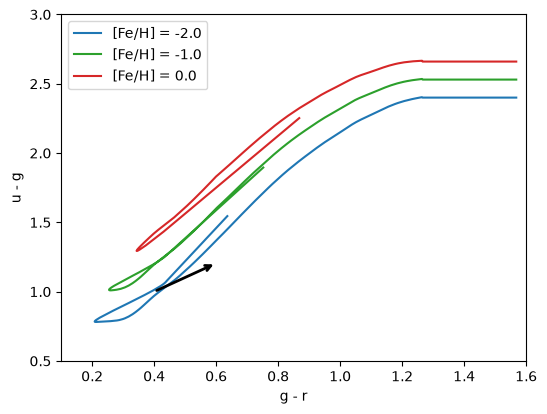

In [10]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for feh, line_color in [(-2.0, 'tab:blue'), (-1.0, 'tab:green'), (0.0, 'tab:red')]:
    track = locus[np.isclose(locus['FeH'], feh) & in_range]
    ax.plot(track['gr'], track['ug'], color=line_color, label=f'[Fe/H] = {feh}')

start = np.array([0.4, 1.0])
shift = 0.5 * np.array([REDDENING['gr'], REDDENING['ug']])
ax.annotate('', xy=start + shift, xytext=start, arrowprops=dict(arrowstyle='->', lw=2))
ax.set(xlim=(0.1, 1.6), ylim=(0.5, 3.0), xlabel='g - r', ylabel='u - g')
ax.legend()
plt.show()

## 5. Priors

The prior for $M_r$ and [Fe/H] describes which stars we expect to see at a given apparent magnitude. Bright stars
are mostly nearby stars in the Galactic disk, where metallicities are close to solar. Among faint stars we see
more distant stars of the Galactic halo, which are old and metal-poor. We therefore make a separate prior map
for each bin of apparent $r$ magnitude.

Each map is a Gaussian kernel density estimate (KDE) of the ([Fe/H], $M_r$) values of the stars in that bin. A
KDE is a smooth histogram: every star is replaced by a small two-dimensional Gaussian, and the Gaussians are
added up. With real data the maps would come from a model of the Milky Way for the observed part of the sky.
Here we build them from the true values of our simulated stars. That makes the prior a little too good, because
it is made from the very stars we fit, but with this many stars the effect is small.

The catalog has no stars fainter than $r = 26$, so the two faintest bins borrow the map of the $r = 26$ bin.

In [11]:
def build_prior_maps(catalog, min_stars=100):
    """One KDE map of ([Fe/H], Mr) per r bin, on the PRIOR_FEH x PRIOR_MR grid. Returns (n_bins, 96, 36)."""
    feh_2d, mr_2d = np.meshgrid(PRIOR_FEH, PRIOR_MR)
    points = np.vstack([feh_2d.ravel(), mr_2d.ravel()])

    stars_in_bin = []
    for r in R_BINS:
        in_bin = (catalog['rmag0'] > r - R_HALF_WIDTH) & (catalog['rmag0'] < r + R_HALF_WIDTH)
        stars_in_bin.append(catalog[in_bin])
    usable = [i for i, s in enumerate(stars_in_bin) if len(s) >= min_stars]

    maps = []
    for i in range(len(R_BINS)):
        sample = stars_in_bin[min(usable, key=lambda k: abs(k - i))]   # nearest bin with enough stars
        kde = gaussian_kde(np.vstack([sample['FeH'], sample['Mr']]))
        maps.append(kde(points).reshape(feh_2d.shape))
    return np.array(maps)


if FORCE_RERUN or not PRIOR_FILE.exists():
    # always built from the full catalog, even if N_STARS is set
    np.savez(PRIOR_FILE, feh=PRIOR_FEH, mr=PRIOR_MR, maps=build_prior_maps(read_catalog(CATALOG_FILE)))
prior_maps = np.load(PRIOR_FILE)['maps']
print('prior maps:', prior_maps.shape)

prior maps: (27, 96, 36)


Five of the 27 maps, on a logarithmic scale (darker means more stars). You can see two groups: disk stars near
[Fe/H] = −0.5 and halo stars near [Fe/H] = −1.5. Toward fainter $r$ both move down to fainter $M_r$, and the halo
group becomes more important.

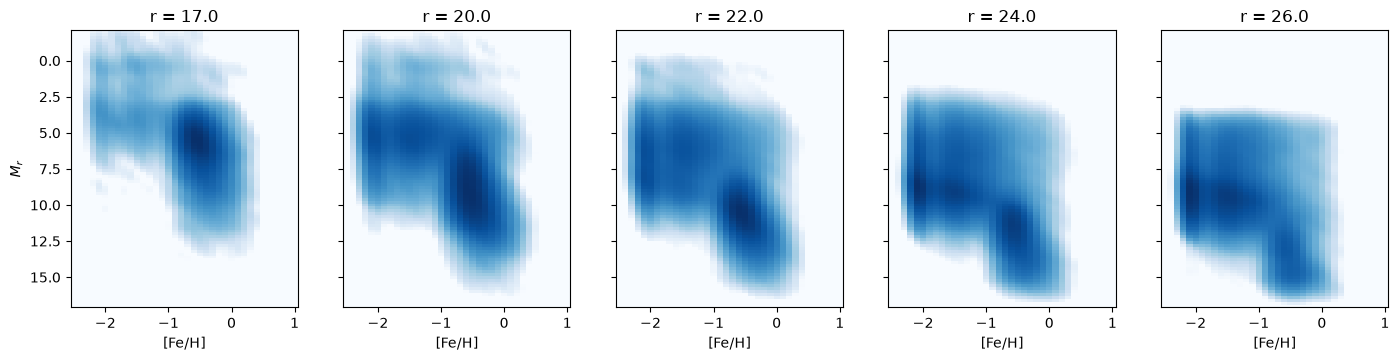

In [12]:
fig, axs = plt.subplots(1, 5, figsize=(17, 3.6), sharey=True)
for ax, i in zip(axs, [6, 12, 16, 20, 24]):
    ax.pcolormesh(PRIOR_FEH, PRIOR_MR, prior_maps[i] / prior_maps[i].max(),
                  cmap='Blues', norm=LogNorm(1e-3, 1), shading='nearest')
    ax.set_title(f'r = {R_BINS[i]:.1f}')
    ax.set_xlabel('[Fe/H]')
axs[0].set_ylabel('$M_r$')
axs[0].invert_yaxis()   # the axes are shared, so this flips all five panels
plt.show()

The prior maps have their own grid, so we interpolate them onto the points of our model grid. Each star then
uses the map of the $r$ bin whose center is closest to its measured $r$.

In [13]:
def prior_on_grid(prior_maps, grid):
    """Interpolate each prior map onto the model grid. Returns an array of shape (n_bins, number of grid points)."""
    feh_2d, mr_2d = np.meshgrid(PRIOR_FEH, PRIOR_MR)
    map_points = np.column_stack([feh_2d.ravel(), mr_2d.ravel()])
    grid_points = (grid['FeH'].to_numpy(), grid['Mr'].to_numpy())
    return np.array([griddata(map_points, m.ravel(), grid_points, method='linear') for m in prior_maps])


def prior_index(r):
    """Index of the r bin closest to r. Stars outside 14 < r < 27 use the first or the last bin."""
    position = np.interp(r, R_BINS, np.arange(len(R_BINS)))   # fractional bin number, e.g. 12.6
    return (position + 0.5).astype(int)                        # rounded to the nearest bin


prior = prior_on_grid(prior_maps, grid)
print('prior on the model grid:', prior.shape)
print('bins used for r = 13, 20.3 and 30:', prior_index(np.array([13, 20.3, 30])))

prior on the model grid: (27, 3875)
bins used for r = 13, 20.3 and 30: [ 0 13 26]


## 6. Estimating the parameters of one star

Now we can put everything together. For one star:

1. find the allowed $A_r$ values, from 0 to $1.3\,A_r^{\mathrm{map}} + 0.1$;
2. compute $\chi^2$ at every point of the 3-D grid, and from it the likelihood $e^{-\chi^2/2}$;
3. copy the prior map along the $A_r$ axis (the dust prior is flat) and multiply by the likelihood to get the
   posterior;
4. add up the posterior over two axes at a time, to get the distributions of $M_r$, [Fe/H] and $A_r$;
5. take the mean and the standard deviation of each distribution.

All 3-D arrays have their axes in the order ([Fe/H], $M_r$, $A_r$). Adding up over axes 0 and 2 therefore leaves
the distribution of $M_r$, and so on.

The distributions are normalized so that $\sum_k p_k \Delta x = 1$, where $\Delta x$ is the grid step. For a
distribution $p_k$ on grid values $x_k$ the mean and standard deviation are

$$ \bar x = \frac{\sum_k x_k p_k}{\sum_k p_k}, \qquad
   \sigma = \sqrt{\frac{\sum_k (x_k - \bar x)^2 p_k}{\sum_k p_k}} . $$

We also keep the smallest $\chi^2$. It tells us how well the best model fits: with four colors and three fitted
parameters, a good fit typically has a value around 1. If a star's colors are far from every model, the likelihood becomes zero everywhere and the
results come out as NaN.

In [14]:
RESULT_COLUMNS = ['MrEst', 'MrEstUnc', 'FeHEst', 'FeHEstUnc', 'ArEst', 'ArEstUnc', 'chi2min']


def normalize(p, step):
    return p / np.sum(p) / step


def marginals(cube, d_mr, d_feh, d_ar):
    """Distributions of Mr, [Fe/H] and Ar from an array with axes ([Fe/H], Mr, Ar)."""
    p_mr = normalize(np.sum(cube, axis=(0, 2)), d_mr)
    p_feh = normalize(np.sum(cube, axis=(1, 2)), d_feh)
    p_ar = normalize(np.sum(cube, axis=(0, 1)), d_ar)
    return p_mr, p_feh, p_ar


def mean_and_std(x, p):
    mean = np.sum(x * p) / np.sum(p)
    std = np.sqrt(np.sum((x - mean)**2 * p) / np.sum(p))
    return mean, std


def bayes_one_star(colors, errors, ar_max, prior_2d, return_arrays=False):
    """Estimate Mr, [Fe/H] and Ar of one star. prior_2d is its prior map on the model grid, shape (n_feh, n_mr)."""
    ar_name, ar = choose_ar_grid(ar_max)
    model = model_colors[ar_name][:, :, :ar.size, :]

    chi2 = np.zeros(model.shape[:-1])                  # one value per grid point
    for c in range(len(COLORS)):
        # model[..., c] is color number c at every grid point
        chi2 += ((colors[c] - model[..., c]) / errors[c]) ** 2
    likelihood = np.exp(-0.5 * chi2)

    # the same prior map for every Ar value: add an Ar axis and repeat the map along it
    prior_3d = np.repeat(prior_2d[:, :, np.newaxis], ar.size, axis=2)
    posterior = prior_3d * likelihood

    steps = (mr_grid[1] - mr_grid[0], feh_grid[1] - feh_grid[0], ar[1] - ar[0])
    p_mr, p_feh, p_ar = marginals(posterior, *steps)
    mr, mr_err = mean_and_std(mr_grid, p_mr)
    feh, feh_err = mean_and_std(feh_grid, p_feh)
    a, a_err = mean_and_std(ar, p_ar)
    result = [mr, mr_err, feh, feh_err, a, a_err, chi2.min()]

    if not return_arrays:
        return result
    arrays = {'prior': prior_3d, 'likelihood': likelihood, 'posterior': posterior, 'ar': ar,
              'marginals': {'prior': marginals(prior_3d, *steps),
                            'likelihood': marginals(likelihood, *steps),
                            'posterior': (p_mr, p_feh, p_ar)}}
    return result, arrays

Let's try it on one star. Row 1021 of the catalog is a metal-poor star close to the main-sequence turnoff, the
point where stars start to leave the main sequence. At $r \approx 22.5$ it is fairly faint, so its colors are
good but not perfect.

The prior for all grid points is stored as one long row per $r$ bin, so we reshape the star's row back into a
([Fe/H], $M_r$) map. With the estimates of $M_r$ and $A_r$ we can already compute the star's distance from the
equation in the background section: $d = 10^{(r - M_r - A_r)/5 + 1}$ pc.

In [15]:
ROW = 1021   # try other rows as well
star = read_catalog(CATALOG_FILE, nrows=ROW + 1).iloc[ROW]

colors = star[COLORS].to_numpy(float)
errors = star[[c + 'Err' for c in COLORS]].to_numpy(float)
ar_max = AR_SCALE * star['Ar'] + AR_OFFSET
prior_2d = prior[prior_index(star['rmag'])].reshape(feh_grid.size, mr_grid.size)

estimate, arrays = bayes_one_star(colors, errors, ar_max, prior_2d, return_arrays=True)

print(f"r = {star['rmag']:.2f}, colors {np.round(colors, 3)}, errors {np.round(errors, 3)}")
print()
print('          true   estimate')
for name, k in [('Mr', 0), ('FeH', 2), ('Ar', 4)]:
    print(f'{name:>6} {star[name]:7.2f}   {estimate[k]:6.2f} +- {estimate[k + 1]:.2f}')
print(f'smallest chi^2: {estimate[6]:.2f}')

true_distance = 10 ** (star['DM'] / 5 + 1)
estimated_distance = 10 ** ((star['rmag'] - estimate[0] - estimate[4]) / 5 + 1)
print(f'distance: true {true_distance / 1000:.1f} kpc, estimated {estimated_distance / 1000:.1f} kpc')

r = 22.49, colors [0.973 0.348 0.129 0.022], errors [0.039 0.011 0.011 0.016]

          true   estimate
    Mr    4.59     4.66 +- 0.39
   FeH   -1.52    -1.53 +- 0.18
    Ar    0.15     0.12 +- 0.08
smallest chi^2: 1.15
distance: true 35.5 kpc, estimated 34.9 kpc


All three estimates are within their uncertainties of the true values. To see how the answer comes about, here
are slices through the three arrays at the most probable $A_r$. The color scale is logarithmic, and white means
less than a millionth of the maximum. The red circle marks the true values.

The prior (left) is broad. The likelihood (middle) has two separate islands: a star just above the turnoff and a
star just below it can have almost the same colors. The posterior (right) is the product of the two. The prior
makes the lower island much more probable, and that is indeed where the true values are.

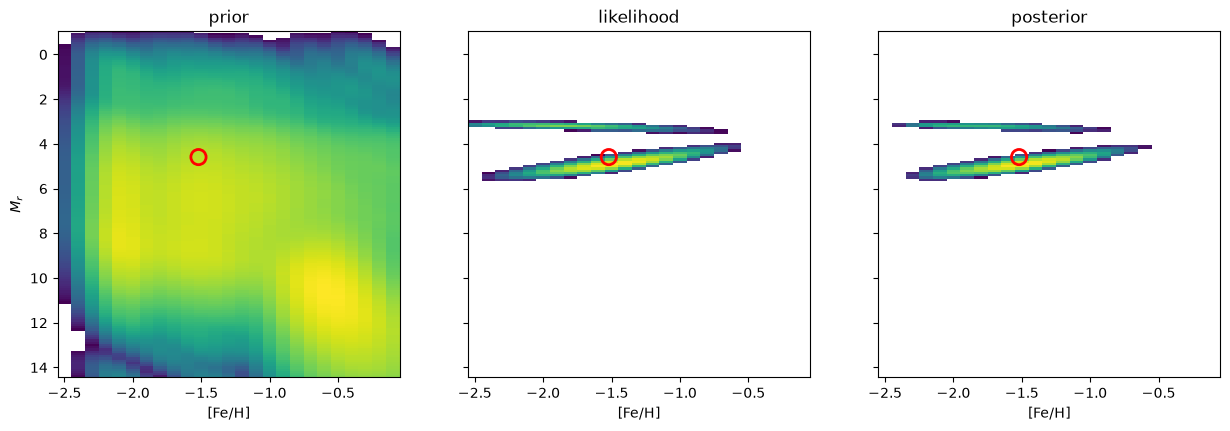

In [16]:
k_best = np.argmax(arrays['marginals']['posterior'][2])   # index of the most probable Ar

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, name in zip(axs, ['prior', 'likelihood', 'posterior']):
    image = arrays[name][:, :, k_best]
    image = image / image.max()
    image[image < 1e-6] = np.nan   # shown as white
    ax.pcolormesh(feh_grid, mr_grid, image.T, cmap='viridis', norm=LogNorm(1e-6, 1), shading='nearest')
    ax.scatter(star['FeH'], star['Mr'], s=120, facecolors='none', edgecolors='red', lw=2)
    ax.set_title(name)
    ax.set_xlabel('[Fe/H]')
axs[0].set_ylabel('$M_r$')
axs[0].invert_yaxis()
plt.show()

The same, added up into the distributions of each parameter: prior in blue, likelihood in green, posterior in red.
The black line is the true value and the dashed red line is the estimate.

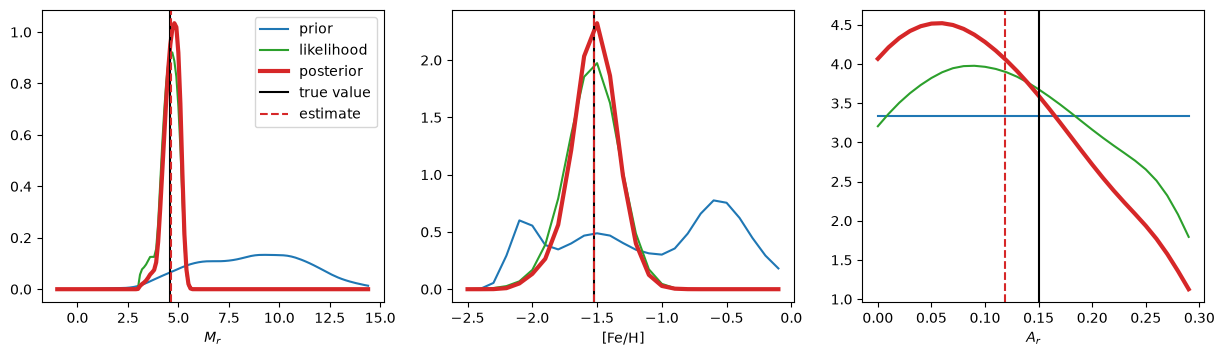

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3.8))
x_values = [mr_grid, feh_grid, arrays['ar']]
for j, (ax, name, label) in enumerate(zip(axs, ['Mr', 'FeH', 'Ar'], ['$M_r$', '[Fe/H]', '$A_r$'])):
    for kind, line_color in [('prior', 'tab:blue'), ('likelihood', 'tab:green'), ('posterior', 'tab:red')]:
        width = 3 if kind == 'posterior' else 1.5
        ax.plot(x_values[j], arrays['marginals'][kind][j], color=line_color, lw=width, label=kind)
    ax.axvline(star[name], color='k', label='true value')
    ax.axvline(estimate[2 * j], color='tab:red', ls='--', label='estimate')
    ax.set_xlabel(label)
axs[0].legend()
plt.show()

Try a few other rows by changing `ROW`. For fainter stars ($r \approx 24$) the likelihood gets much wider and the
estimate depends more on the prior.

## 7. Running on all stars

`bayes_one_star` needs about 0.1 s per star, which for 600,000 stars is 17 hours. We can get exactly the same
numbers much faster with three observations.

1. $\chi^2$ is a parabola in $A_r$. Write $d = (\mathrm{measured} - \mathrm{table})/\mathrm{error}$ and
   $q = \mathrm{reddening}/\mathrm{error}$ for each color. Then $\chi^2 = a - 2bA_r + sA_r^2$ with
   $a = \sum d^2$, $b = \sum dq$ and $s = \sum q^2$. These sums are computed once for each ([Fe/H], $M_r$) point,
   instead of once for every $A_r$ value as well.
2. The prior does not depend on $A_r$, so we can add up the likelihood over $A_r$ first and multiply by the prior
   afterwards.
3. The lowest point of the parabola tells us the largest posterior a ([Fe/H], $M_r$) point can reach. Points that
   cannot come within a factor $e^{-50}$ of the best one make no difference to the sums, so we skip them.

In [18]:
SKIP_BELOW = 50.0   # skip grid points whose best log-posterior is more than this below the maximum


def fast_setup(grid, prior):
    """Things the fast version needs, computed once."""
    with np.errstate(divide='ignore'):
        log_prior = np.log(prior)
    return {'table_colors': np.stack([grid[c].to_numpy(float) for c in COLORS], axis=-1),   # (grid points, 4)
            'reddening': np.array([REDDENING[c] for c in COLORS]),
            'prior': prior, 'log_prior': log_prior}


def bayes_one_star_fast(colors, errors, ar_max, r_bin, setup):
    """Same result as bayes_one_star, using the three shortcuts."""
    _, ar = choose_ar_grid(ar_max)
    d_ar = ar[1] - ar[0]

    # 1. chi2 = a - 2 b Ar + s Ar^2 at every ([Fe/H], Mr) point
    d = (colors - setup['table_colors']) / errors
    q = setup['reddening'] / errors
    a = np.sum(d * d, axis=1)   # sums over the four colors; @ is a matrix product, here also a sum over colors
    b = d @ q
    s = q @ q

    # 3. smallest chi2 of each point on the Ar grid, from the two grid values around the bottom (Ar = b / s)
    k_low = np.clip(np.floor(b / s / d_ar).astype(int), 0, ar.size - 1)   # grid index just below the bottom
    k_high = np.minimum(k_low + 1, ar.size - 1)
    chi2_low = a + ar[k_low] * (s * ar[k_low] - 2.0 * b)
    chi2_high = a + ar[k_high] * (s * ar[k_high] - 2.0 * b)
    chi2_best = np.minimum(chi2_low, chi2_high)
    best_log_posterior = setup['log_prior'][r_bin] - 0.5 * chi2_best
    keep = np.flatnonzero(best_log_posterior >= np.max(best_log_posterior) - SKIP_BELOW)

    chi2 = a[keep, None] + ar[None, :] * (s * ar[None, :] - 2.0 * b[keep, None])
    likelihood = np.exp(-0.5 * chi2)   # shape (points kept, n_ar)

    # 2. add up over Ar first, then multiply by the prior
    prior = setup['prior'][r_bin]
    summed = np.zeros(prior.size)
    summed[keep] = likelihood.sum(axis=1)
    posterior_2d = (prior * summed).reshape(feh_grid.size, mr_grid.size)
    p_mr = normalize(posterior_2d.sum(axis=0), mr_grid[1] - mr_grid[0])
    p_feh = normalize(posterior_2d.sum(axis=1), feh_grid[1] - feh_grid[0])
    p_ar = normalize(prior[keep] @ likelihood, d_ar)

    mr, mr_err = mean_and_std(mr_grid, p_mr)
    feh, feh_err = mean_and_std(feh_grid, p_feh)
    a_est, a_err = mean_and_std(ar, p_ar)
    return [mr, mr_err, feh, feh_err, a_est, a_err, chi2_best.min()]


def star_inputs(stars):
    """Colors, color errors, Ar maximum and prior bin of every star, as arrays."""
    colors = stars[COLORS].to_numpy(float)
    errors = stars[[c + 'Err' for c in COLORS]].to_numpy(float)
    ar_max = AR_SCALE * stars['Ar'].to_numpy(float) + AR_OFFSET
    return colors, errors, ar_max, prior_index(stars['rmag'].to_numpy(float))


def bayes_many(colors, errors, ar_max, r_bin, setup):
    """Run bayes_one_star_fast on many stars."""
    results = np.full((len(colors), len(RESULT_COLUMNS)), np.nan)
    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):   # stars without a solution give NaN
        for i in range(len(colors)):
            results[i] = bayes_one_star_fast(colors[i], errors[i], ar_max[i], r_bin[i], setup)
    return results


setup = fast_setup(grid, prior)

Before using it, we check on 200 stars that the fast version gives the same numbers as `bayes_one_star`. The
differences should be tiny, at the level of rounding errors.

In [19]:
test_stars = read_catalog(CATALOG_FILE, nrows=200)
inputs = star_inputs(test_stars)

slow = []
with np.errstate(divide='ignore', invalid='ignore'):
    for colors_i, errors_i, ar_max_i, r_bin_i in zip(*inputs):
        prior_2d = prior[r_bin_i].reshape(feh_grid.size, mr_grid.size)
        slow.append(bayes_one_star(colors_i, errors_i, ar_max_i, prior_2d))
fast = bayes_many(*inputs, setup)

print('largest difference:', np.nanmax(np.abs(fast - np.array(slow))))
assert np.allclose(fast, slow, rtol=1e-10, atol=1e-9, equal_nan=True)

largest difference: 8.137934770502397e-14


The stars are independent of each other, so we can split the catalog into chunks and process the chunks on all
CPU cores at the same time. The helper processes are started with "fork", which gives each of them a copy of the
notebook's memory, including the two global variables that hold the model and the inputs. On systems without
fork everything runs in one process.

The results are saved, together with the true values, and loaded on later runs.

In [20]:
CHUNK = 2000
_setup, _inputs = None, None   # read by the helper processes


def _run_chunk(bounds):
    start, stop = bounds
    colors, errors, ar_max, r_bin = _inputs
    return start, bayes_many(colors[start:stop], errors[start:stop], ar_max[start:stop], r_bin[start:stop], _setup)


def run_all(stars, setup):
    global _setup, _inputs
    _setup, _inputs = setup, star_inputs(stars)
    chunks = [(start, min(start + CHUNK, len(stars))) for start in range(0, len(stars), CHUNK)]
    results = np.full((len(stars), len(RESULT_COLUMNS)), np.nan)
    t0 = time.time()
    if N_WORKERS > 1 and 'fork' in mp.get_all_start_methods():
        with mp.get_context('fork').Pool(N_WORKERS) as pool:
            for start, part in pool.imap_unordered(_run_chunk, chunks):
                results[start:start + len(part)] = part
    else:
        for chunk in chunks:
            start, part = _run_chunk(chunk)
            results[start:start + len(part)] = part
    print(f'{len(stars):,} stars in {(time.time() - t0) / 60:.1f} minutes')
    return pd.DataFrame(results, columns=RESULT_COLUMNS)


if FORCE_RERUN or not RESULTS_FILE.exists():
    estimates = run_all(catalog, setup)
    truth = catalog[['FeH', 'Mr', 'Ar', 'DM', 'rmag', 'uErr', 'gErr', 'rErr', 'iErr', 'zErr']]
    results = pd.concat([truth.reset_index(drop=True), estimates], axis=1)
    results.to_csv(RESULTS_FILE, index=False, float_format='%.10g')

results = pd.read_csv(RESULTS_FILE)
print(f'{len(results):,} stars, {results["MrEst"].isna().sum()} of them without a solution')

619,581 stars, 846 of them without a solution


## 8. How good are the estimates?

We compare the estimates with the true values for all stars that have a solution. We leave out stars with a
magnitude error above 5 mag in any filter; such a star was not really detected in that filter.

With about 435,000 stars the points overlap heavily, so each point is colored by how crowded its surroundings
are. That density comes from a KDE fitted to 200 randomly chosen points, which is quick and good enough for
coloring.

435,739 stars


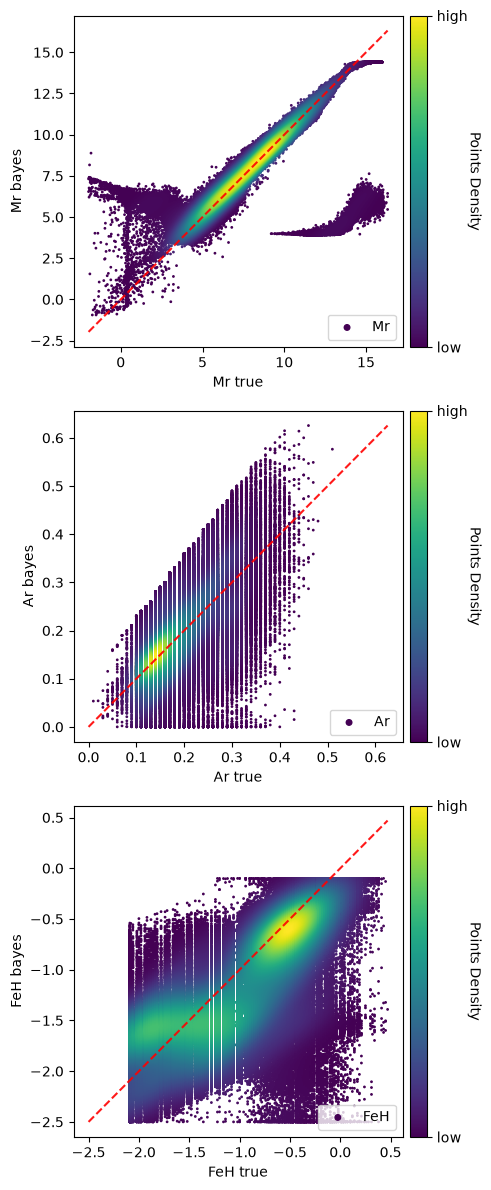

In [21]:
has_solution = np.isfinite(results[['MrEst', 'FeHEst', 'ArEst']]).all(axis=1)
detected = (results[['uErr', 'gErr', 'rErr', 'iErr', 'zErr']] < 5).all(axis=1)
good = results[has_solution & detected]
print(f'{len(good):,} stars')


def point_density(x, y, n_kde=200):
    """Density around each point, from a KDE of n_kde random points. Returns x, y, density, densest last."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    pick = np.random.default_rng(SEED).choice(x.size, size=min(n_kde, x.size))
    density = gaussian_kde(np.vstack([x[pick], y[pick]]), bw_method='silverman')(np.vstack([x, y]))
    order = density.argsort()
    return x[order], y[order], density[order]


fig, axs = plt.subplots(3, 1, figsize=(5, 12))
for ax, name in zip(axs, ['Mr', 'Ar', 'FeH']):
    x, y, density = point_density(good[name], good[name + 'Est'])
    points = ax.scatter(x, y, c=density, s=1, cmap='viridis', label=name, rasterized=True)

    low, high = min(x.min(), y.min()), max(x.max(), y.max())
    pad = 0.05 * (high - low)
    ax.plot([low, high], [low, high], color='red', ls='--', alpha=0.9)
    ax.set(xlim=(low - pad, high + pad), ylim=(low - pad, high + pad), xlabel=f'{name} true', ylabel=f'{name} bayes')
    ax.legend(loc='lower right', markerscale=4)

    bar = plt.colorbar(points, ax=ax, pad=0.02, ticks=[density.min(), density.max()])
    bar.ax.set_yticklabels(['low', 'high'])
    bar.set_label('Points Density', rotation=270, labelpad=10)

fig.tight_layout()
fig.savefig(OUT_DIR / 'bayes_vs_true.png', dpi=200)
plt.show()

To put numbers on it, we look at the differences estimate − truth. Their median shows whether the estimates are
biased. For the scatter we use $\sigma_G = 0.741\,(q_{75} - q_{25})$, computed from the 25th and 75th percentiles.
For a Gaussian distribution it equals the standard deviation, but it is not thrown off by a few large outliers.

In [22]:
def sigma_g(x):
    return 0.741 * (np.percentile(x, 75) - np.percentile(x, 25))


summary = {}
for name in ['Mr', 'Ar', 'FeH']:
    difference = good[name + 'Est'] - good[name]
    summary[name] = {'median': np.median(difference), 'sigma_G': sigma_g(difference)}
pd.DataFrame(summary).round(3)

,Mr,Ar,FeH
median,0.024,-0.002,-0.101
sigma_G,0.306,0.046,0.379


What the figure shows:

- $M_r$ is recovered well for most stars. The exceptions are mainly giants ($M_r < 3$) that were taken for
  main-sequence stars, because the two can have very similar colors. No estimate is fainter than 14.4, the edge
  of our grid.
- $A_r$ scatters widely around the true value. As we saw in section 4, dust moves stars almost along the locus.
  The vertical stripes are there because the true $A_r$ values in the catalog are rounded to 0.01.
- [Fe/H] shows the disk (around −0.5) and the halo (around −1.5). For many faint stars $u-g$ is so noisy that
  the posterior simply follows the prior, which at faint magnitudes is dominated by the halo. That is why so many
  estimates pile up near −1.5. No estimate is above −0.1, the edge of our grid. Part of the [Fe/H] scatter, and
  the bias of about −0.1, come from small differences between the colors used to simulate the catalog and our
  table, mostly in $u-g$ for $M_r$ below about 8.

The faint stars are the main problem. To see this, we split the stars into 1-mag bins of $r$ and compute the
scatter $\sigma_G$ in each bin. The right panel shows the typical error of the $u-g$ color in the same bins.

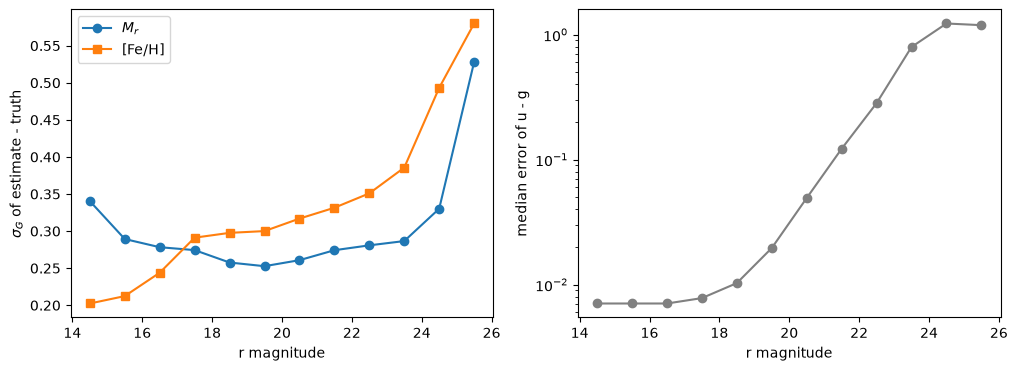

,r,stars,Mr,FeH,ug error
0,14.5,2489,0.34,0.20,0.01
1,15.5,3975,0.29,0.21,0.01
2,16.5,6060,0.28,0.24,0.01
3,17.5,8907,0.27,0.29,0.01
4,18.5,13276,0.26,0.30,0.01
5,19.5,20293,0.25,0.30,0.02
6,20.5,31814,0.26,0.32,0.05
7,21.5,49050,0.27,0.33,0.12
8,22.5,72503,0.28,0.35,0.28
9,23.5,101430,0.29,0.39,0.80


In [23]:
r_edges = np.arange(14, 27)
rows = []
for low, high in zip(r_edges[:-1], r_edges[1:]):
    in_bin = good[(good['rmag'] >= low) & (good['rmag'] < high)]
    rows.append({'r': low + 0.5,
                 'stars': len(in_bin),
                 'Mr': sigma_g(in_bin['MrEst'] - in_bin['Mr']),
                 'FeH': sigma_g(in_bin['FeHEst'] - in_bin['FeH']),
                 'ug error': np.median(np.hypot(in_bin['uErr'], in_bin['gErr']))})
by_r = pd.DataFrame(rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(by_r['r'], by_r['Mr'], 'o-', label='$M_r$')
ax1.plot(by_r['r'], by_r['FeH'], 's-', label='[Fe/H]')
ax1.set(xlabel='r magnitude', ylabel='$\\sigma_G$ of estimate - truth')
ax1.legend()
ax2.semilogy(by_r['r'], by_r['ug error'], 'o-', color='grey')
ax2.set(xlabel='r magnitude', ylabel='median error of u - g')
plt.show()
by_r.round(2)

For bright stars [Fe/H] is measured to 0.2 to 0.3 dex. Toward fainter stars the $u-g$ error grows from about
0.01 mag to more than 1 mag, and the [Fe/H] scatter grows with it to about 0.6 dex,
which is roughly the width of the prior itself: the colors no longer say much about the metallicity. $M_r$ holds
up much better, at about 0.3 mag, until $r \approx 24$, because it depends mostly on the other colors.

## 9. Distances

Finally we turn the estimates into distances, $d = 10^{(r - M_r - A_r)/5 + 1}$ pc, and compare them with the true
distances from the true distance modulus. An error $\delta$ in $M_r + A_r$ changes the distance by a factor
$10^{\delta/5}$, which for small $\delta$ is about $1 + 0.46\,\delta$. So a scatter of 0.3 mag in $M_r$ should
give a distance scatter of roughly 14%.

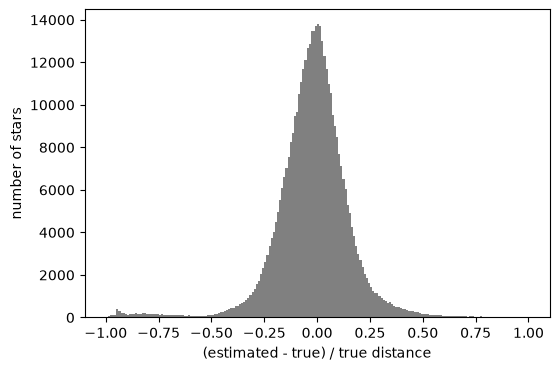

all stars: median -0.011, sigma_G 0.134
14 < r < 22: sigma_G 0.113
22 < r < 24: sigma_G 0.123
24 < r < 26: sigma_G 0.176


In [24]:
true_distance = 10 ** (good['DM'] / 5 + 1)
estimated_distance = 10 ** ((good['rmag'] - good['MrEst'] - good['ArEst']) / 5 + 1)
relative_error = estimated_distance / true_distance - 1

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(relative_error, bins=200, range=(-1, 1), color='grey')
ax.set(xlabel='(estimated - true) / true distance', ylabel='number of stars')
plt.show()

print(f'all stars: median {np.median(relative_error):+.3f}, sigma_G {sigma_g(relative_error):.3f}')
for low, high in [(14, 22), (22, 24), (24, 26)]:
    in_range = (good['rmag'] >= low) & (good['rmag'] < high)
    print(f'{low} < r < {high}: sigma_G {sigma_g(relative_error[in_range]):.3f}')

The distances are unbiased to about 1% and good to about 13% overall, and to about 11% for stars brighter than
$r = 22$. For $24 < r < 26$, where $M_r$ gets worse, it grows to about 18%. The small bump near −1 comes from the
giants that were taken for main-sequence stars: their $M_r$ is too faint by several magnitudes, so they are placed
about ten times too close.